# frozen-distilbert-adapter-peft-imdb


In [1]:
#!pip -q install -U "datasets>=2.19.0" "transformers>=4.41.0" "peft>=0.11.0" "accelerate>=0.30.0" "scikit-learn>=1.3.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.3 MB/s eta 0:00:00


In [2]:
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from transformers.modeling_outputs import SequenceClassifierOutput

from peft import LoraConfig, TaskType, get_peft_model

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
MODEL_CHECKPOINT = "distilbert-base-uncased"

TRAIN_VALID_SUBSAMPLE_SIZE = 10_000
VALIDATION_FRACTION = 0.20

MAX_LENGTH = 256
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 64

NUM_EPOCHS_FULL_FT = 2
NUM_EPOCHS_LORA = 2
NUM_EPOCHS_ADAPTER = 2

GRAD_CLIP_NORM = 1.0
WARMUP_RATIO = 0.06

comparison_results = {}
histories = {}

## Load IMDB & create the shared train, validation, test datasets


In [4]:
imdb = load_dataset("imdb")
imdb

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [5]:
train_valid = imdb["train"].shuffle(seed=SEED).select(range(TRAIN_VALID_SUBSAMPLE_SIZE))

try:
    split = train_valid.train_test_split(
        test_size=VALIDATION_FRACTION,
        seed=SEED,
        stratify_by_column="label",
    )
except Exception as e:
    print("Stratified split was not available in this environment; using random split.")
    print("Reason:", repr(e))
    split = train_valid.train_test_split(
        test_size=VALIDATION_FRACTION,
        seed=SEED,
    )

raw_train = split["train"]
raw_val = split["test"]
raw_test = imdb["test"]

print(f"Training examples:   {len(raw_train):,}")
print(f"Validation examples: {len(raw_val):,}")
print(f"Test examples:       {len(raw_test):,}  (full imdb['test'])")

Training examples:   8,000
Validation examples: 2,000
Test examples:       25,000  (full imdb['test'])


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized_train = raw_train.map(tokenize_batch, batched=True, remove_columns=["text"])
tokenized_val = raw_val.map(tokenize_batch, batched=True, remove_columns=["text"])
tokenized_test = raw_test.map(tokenize_batch, batched=True, remove_columns=["text"])

columns = ["input_ids", "attention_mask", "label"]
tokenized_train.set_format(type="torch", columns=columns)
tokenized_val.set_format(type="torch", columns=columns)
tokenized_test.set_format(type="torch", columns=columns)

train_loader = DataLoader(tokenized_train, batch_size=TRAIN_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(tokenized_val, batch_size=EVAL_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(tokenized_test, batch_size=EVAL_BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
{k: tuple(v.shape) for k, v in batch.items()}

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

{'label': (16,), 'input_ids': (16, 256), 'attention_mask': (16, 256)}

## Shared utility functions


In [7]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total


def print_parameter_report(model, model_name: str):
    trainable, total = count_parameters(model)
    pct = 100.0 * trainable / total
    print(f"{model_name}")
    print(f"  Trainable parameters: {trainable:,}")
    print(f"  Total parameters:     {total:,}")
    print(f"  Trainable fraction:   {pct:.4f}%")
    return trainable, total


def make_optimizer_and_scheduler(model, train_loader, num_epochs, lr, weight_decay):
    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable_parameters, lr=lr, weight_decay=weight_decay)

    num_training_steps = len(train_loader) * num_epochs
    num_warmup_steps = max(1, int(WARMUP_RATIO * num_training_steps))

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
    )
    return optimizer, scheduler


@torch.no_grad()
def evaluate_loss(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_examples = 0

    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("label")

        outputs = model(**batch, labels=labels)
        loss = outputs.loss

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


def train_model(
    model,
    train_loader,
    val_loader,
    num_epochs,
    lr,
    weight_decay,
    grad_clip_norm=1.0,
    model_name="model",
):
    model.to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(
        model=model,
        train_loader=train_loader,
        num_epochs=num_epochs,
        lr=lr,
        weight_decay=weight_decay,
    )

    history = {"epoch": [], "train_loss": [], "val_loss": []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        total_examples = 0

        progress = tqdm(train_loader, desc=f"{model_name} | epoch {epoch}/{num_epochs}", leave=False)

        for batch in progress:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop("label")

            optimizer.zero_grad(set_to_none=True)
            outputs = model(**batch, labels=labels)
            loss = outputs.loss
            loss.backward()

            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    max_norm=grad_clip_norm,
                )

            optimizer.step()
            scheduler.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            total_examples += batch_size

            progress.set_postfix({"loss": f"{loss.item():.4f}"})

        train_loss = running_loss / total_examples
        val_loss = evaluate_loss(model, val_loader, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"{model_name} | epoch {epoch:02d}: "
            f"train loss = {train_loss:.4f}, validation loss = {val_loss:.4f}"
        )

    return history


@torch.no_grad()
def evaluate_metrics(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("label")

        outputs = model(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }


def plot_loss(history, title):
    plt.figure(figsize=(7, 5))
    plt.plot(history["epoch"], history["train_loss"], marker="o", label="Training loss")
    plt.plot(history["epoch"], history["val_loss"], marker="o", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.xticks(history["epoch"])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Hyperparameter

In [8]:
hyperparameter_table = pd.DataFrame(
    [
        {
            "Model": "Full FT",
            "Trainable components": "All DistilBERT + classification head",
            "Learning rate": 2e-5,
            "Batch size": TRAIN_BATCH_SIZE,
            "Epochs": NUM_EPOCHS_FULL_FT,
            "Max sequence length": MAX_LENGTH,
            "Weight decay": 0.01,
            "Gradient clipping": GRAD_CLIP_NORM,
            "Extra PEFT settings": "None",
        },
        {
            "Model": "LoRA",
            "Trainable components": "LoRA q/v projections + classifier head",
            "Learning rate": 1e-4,
            "Batch size": TRAIN_BATCH_SIZE,
            "Epochs": NUM_EPOCHS_LORA,
            "Max sequence length": MAX_LENGTH,
            "Weight decay": 0.01,
            "Gradient clipping": GRAD_CLIP_NORM,
            "Extra PEFT settings": "r=8, alpha=16, dropout=0.10, target_modules=['q_lin','v_lin']",
        },
        {
            "Model": "Adapter",
            "Trainable components": "Bottleneck adapter + classifier head",
            "Learning rate": 1e-3,
            "Batch size": TRAIN_BATCH_SIZE,
            "Epochs": NUM_EPOCHS_ADAPTER,
            "Max sequence length": MAX_LENGTH,
            "Weight decay": 0.01,
            "Gradient clipping": GRAD_CLIP_NORM,
            "Extra PEFT settings": "bottleneck r=64, ReLU, adapter dropout=0.10, near-identity init",
        },
    ]
)

display(hyperparameter_table)

,Model,Trainable components,Learning rate,Batch size,Epochs,Max sequence length,Weight decay,Gradient clipping,Extra PEFT settings
0,Full FT,All DistilBERT + classification head,0.00002,16,2,256,0.01,1.0,None
1,LoRA,LoRA q/v projections + classifier head,0.00010,16,2,256,0.01,1.0,"r=8, alpha=16, dropout=0.10, target_modules=['..."
2,Adapter,Bottleneck adapter + classifier head,0.00100,16,2,256,0.01,1.0,"bottleneck r=64, ReLU, adapter dropout=0.10, n..."


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full fine-tuning DistilBERT
  Trainable parameters: 66,955,010
  Total parameters:     66,955,010
  Trainable fraction:   100.0000%


Full FT | epoch 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Full FT | epoch 01: train loss = 0.3662, validation loss = 0.2608


Full FT | epoch 2/2:   0%|          | 0/500 [00:00<?, ?it/s]

Full FT | epoch 02: train loss = 0.1936, validation loss = 0.2915


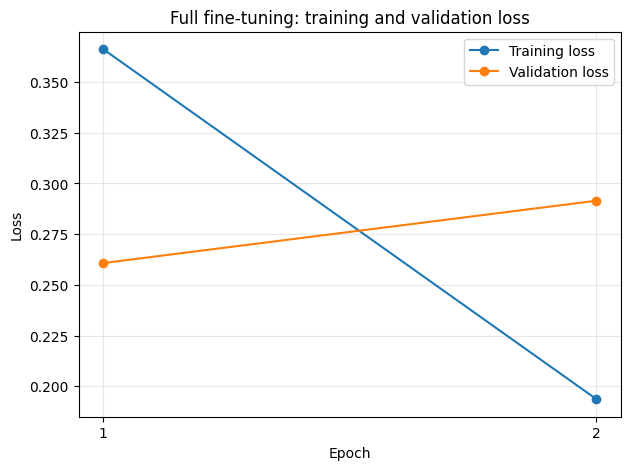

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

{'Model': 'Full FT',
 'Trainable parameters': 66955010,
 'Accuracy': 0.89916,
 'Precision': 0.8881973080214736,
 'Recall': 0.91328,
 'F1': 0.900564035814302}

In [9]:
set_seed(SEED)
clear_memory()

full_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
)

for param in full_model.parameters():
    param.requires_grad = True

full_trainable, full_total = print_parameter_report(full_model, "Full fine-tuning DistilBERT")
assert full_trainable == full_total, "Full fine-tuning should make all parameters trainable."

history_full = train_model(
    model=full_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS_FULL_FT,
    lr=2e-5,
    weight_decay=0.01,
    grad_clip_norm=GRAD_CLIP_NORM,
    model_name="Full FT",
)

histories["Full FT"] = history_full
plot_loss(history_full, "Full fine-tuning: training and validation loss")

full_test_metrics = evaluate_metrics(full_model, test_loader, device)

comparison_results["Full FT"] = {
    "Model": "Full FT",
    "Trainable parameters": full_trainable,
    **full_test_metrics,
}

comparison_results["Full FT"]


In [10]:
del full_model
clear_memory()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA trainable-parameter report from PEFT:
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925
LoRA DistilBERT
  Trainable parameters: 739,586
  Total parameters:     67,694,596
  Trainable fraction:   1.0925%


LoRA | epoch 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


LoRA | epoch 01: train loss = 0.4059, validation loss = 0.2943


LoRA | epoch 2/2:   0%|          | 0/500 [00:00<?, ?it/s]

LoRA | epoch 02: train loss = 0.2988, validation loss = 0.2792


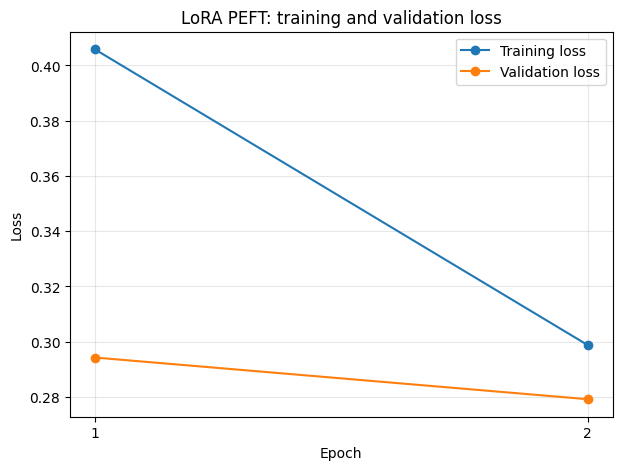

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

{'Model': 'LoRA',
 'Trainable parameters': 739586,
 'Accuracy': 0.87972,
 'Precision': 0.8776354523032859,
 'Recall': 0.88248,
 'F1': 0.8800510590769476}

In [12]:
!pip install -U "torchao>=0.17.0"

set_seed(SEED)
clear_memory()

base_lora_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.10,
    target_modules=["q_lin", "v_lin"],
    bias="none",
    modules_to_save=["pre_classifier", "classifier"],
)

lora_model = get_peft_model(base_lora_model, lora_config)

print("LoRA trainable-parameter report from PEFT:")
lora_model.print_trainable_parameters()
lora_trainable, lora_total = print_parameter_report(lora_model, "LoRA DistilBERT")

history_lora = train_model(
    model=lora_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS_LORA,
    lr=1e-4,
    weight_decay=0.01,
    grad_clip_norm=GRAD_CLIP_NORM,
    model_name="LoRA",
)

histories["LoRA"] = history_lora
plot_loss(history_lora, "LoRA PEFT: training and validation loss")

lora_test_metrics = evaluate_metrics(lora_model, test_loader, device)

comparison_results["LoRA"] = {
    "Model": "LoRA",
    "Trainable parameters": lora_trainable,
    **lora_test_metrics,
}

comparison_results["LoRA"]

In [13]:
del lora_model
del base_lora_model
clear_memory()

# Bottleneck-adapter PEFT model with frozen DistilBERT

In [14]:
class BottleneckAdapter(nn.Module):

    def __init__(self, hidden_size: int, bottleneck_dim: int, dropout: float = 0.10):
        super().__init__()
        self.down = nn.Linear(hidden_size, bottleneck_dim, bias=True)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.up = nn.Linear(bottleneck_dim, hidden_size, bias=True)

        self.reset_parameters_near_identity()

    def reset_parameters_near_identity(self):
        # Small down projection; zero up projection makes residual branch initially zero.
        nn.init.normal_(self.down.weight, mean=0.0, std=1e-3)
        nn.init.zeros_(self.down.bias)

        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, h):
        return h + self.up(self.dropout(self.activation(self.down(h))))


class FrozenDistilBertAdapterClassifier(nn.Module):

    def __init__(
        self,
        model_checkpoint: str,
        num_labels: int = 2,
        bottleneck_dim: int = 64,
        adapter_dropout: float = 0.10,
        classifier_dropout: float = 0.20,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_checkpoint)

        # Freeze all DistilBERT encoder parameters.
        for param in self.encoder.parameters():
            param.requires_grad = False

        hidden_size = self.encoder.config.hidden_size
        self.adapter = BottleneckAdapter(
            hidden_size=hidden_size,
            bottleneck_dim=bottleneck_dim,
            dropout=adapter_dropout,
        )
        self.dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)
        self.loss_fn = nn.CrossEntropyLoss()

    def train(self, mode: bool = True):

        super().train(mode)
        self.encoder.eval()
        return self

    def forward(self, input_ids=None, attention_mask=None, labels=None):

        with torch.no_grad():
            outputs = self.encoder(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True,
            )

        cls_like_embedding = outputs.last_hidden_state[:, 0, :]
        adapted_embedding = self.adapter(cls_like_embedding)
        logits = self.classifier(self.dropout(adapted_embedding))

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits)

In [17]:
set_seed(SEED)
clear_memory()

ADAPTER_BOTTLENECK_DIM = 64

adapter_model = FrozenDistilBertAdapterClassifier(
    model_checkpoint=MODEL_CHECKPOINT,
    num_labels=2,
    bottleneck_dim=ADAPTER_BOTTLENECK_DIM,
    adapter_dropout=0.10,
    classifier_dropout=0.20,
)

assert all(not p.requires_grad for p in adapter_model.encoder.parameters()), "Encoder must be frozen."
assert any(p.requires_grad for p in adapter_model.adapter.parameters()), "Adapter must be trainable."
assert any(p.requires_grad for p in adapter_model.classifier.parameters()), "Classifier must be trainable."

adapter_trainable, adapter_total = print_parameter_report(adapter_model, "Frozen DistilBERT + bottleneck adapter")

print("\nTrainable parameter names:")
for name, param in adapter_model.named_parameters():
    if param.requires_grad:
        print("  ", name, tuple(param.shape))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Frozen DistilBERT + bottleneck adapter
  Trainable parameters: 100,674
  Total parameters:     66,463,554
  Trainable fraction:   0.1515%

Trainable parameter names:
   adapter.down.weight (64, 768)
   adapter.down.bias (64,)
   adapter.up.weight (768, 64)
   adapter.up.bias (768,)
   classifier.weight (2, 768)
   classifier.bias (2,)


Adapter | epoch 1/2:   0%|          | 0/500 [00:00<?, ?it/s]

Adapter | epoch 01: train loss = 0.4506, validation loss = 0.3890


Adapter | epoch 2/2:   0%|          | 0/500 [00:00<?, ?it/s]

Adapter | epoch 02: train loss = 0.3713, validation loss = 0.3614


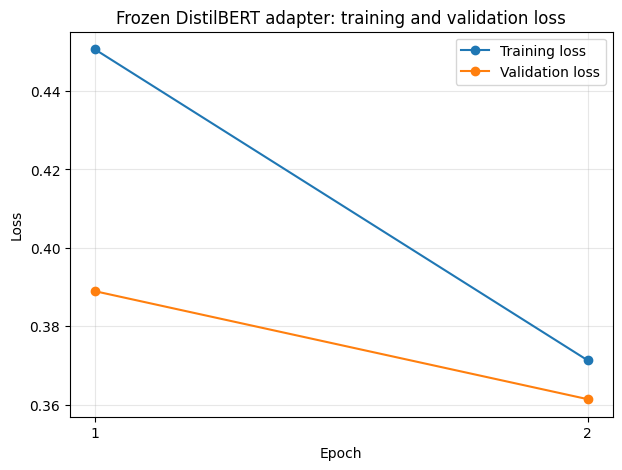

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

{'Model': 'Adapter',
 'Trainable parameters': 100674,
 'Accuracy': 0.84096,
 'Precision': 0.8330207844975778,
 'Recall': 0.85288,
 'F1': 0.8428334255672385}

In [18]:
history_adapter = train_model(
    model=adapter_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS_ADAPTER,
    lr=1e-3,
    weight_decay=0.01,
    grad_clip_norm=GRAD_CLIP_NORM,
    model_name="Adapter",
)

histories["Adapter"] = history_adapter
plot_loss(history_adapter, "Frozen DistilBERT adapter: training and validation loss")

adapter_test_metrics = evaluate_metrics(adapter_model, test_loader, device)

comparison_results["Adapter"] = {
    "Model": "Adapter",
    "Trainable parameters": adapter_trainable,
    **adapter_test_metrics,
}

comparison_results["Adapter"]

In [19]:
del adapter_model
clear_memory()

# Final test-set comparison

In [20]:
comparison_df = pd.DataFrame(
    [
        comparison_results["Full FT"],
        comparison_results["LoRA"],
        comparison_results["Adapter"],
    ]
)

metric_cols = ["Accuracy", "Precision", "Recall", "F1"]
display_df = comparison_df.copy()
display_df["Trainable parameters"] = display_df["Trainable parameters"].map(lambda x: f"{x:,}")
for col in metric_cols:
    display_df[col] = display_df[col].map(lambda x: f"{x:.4f}")

display(display_df)

,Model,Trainable parameters,Accuracy,Precision,Recall,F1
0,Full FT,"66,955,010",0.8992,0.8882,0.9133,0.9006
1,LoRA,"739,586",0.8797,0.8776,0.8825,0.8801
2,Adapter,"100,674",0.8410,0.8330,0.8529,0.8428
